# Apple (AAPL) Hisse Senedi Fiyat Tahmini: LSTM ve GRU Karşılaştırması

Bu projede, PyTorch derin öğrenme kütüphanesi kullanılarak Apple Inc. (AAPL) şirketinin geçmiş hisse senedi fiyatları üzerinden geleceğe yönelik zaman serisi tahmini yapılmıştır. Durağan olmayan (non-stationary) ve karmaşık finansal verilerin modellenmesi için geleneksel yöntemler yerine Derin Öğrenme (Deep Learning) mimarileri tercih edilmiştir.

## Proje Adımları ve Metodoloji

1. **Veri Setinin İndirilmesi:** `yfinance` kütüphanesi kullanılarak Apple'ın 2014-2024 yılları arasındaki 10 yıllık günlük kapanış (Close) fiyatları çekilmiştir.
2. **Keşifsel Veri Analizi:** Ham verinin genel trendini incelemek ve modele verilmeden önceki yapısını anlamak için görselleştirmeler yapılmıştır.
3. **Veri Mühendisliği ve Ön İşleme:** Modelin gradyan hesaplamalarında daha stabil çalışabilmesi için tüm veriler `MinMaxScaler` ile -1 ve 1 aralığına normalize edilmiştir. Modelin serisel bağımlılığı öğrenebilmesi için **"Kayan Pencere" (Sliding Window)** tekniği uygulanmış (lookback=20) ve finansal tahminlerde kritik olan veri sızıntısını (data leakage) engellemek adına veri, rastgele değil kronolojik olarak %80 Train, %20 Test şeklinde ayrılmıştır.
4. **Model Mimarilerinin Kurulumu:** PyTorch kullanılarak geçmiş veri dizilerindeki doğrusal olmayan bağıntıları yakalayabilen **LSTM (Uzun Kısa Süreli Hafıza)** ve **GRU (Geçitli Tekrarlayan Birim)** tabanlı iki farklı mimari inşa edilmiştir.
5. **Optuna ile Hiperparametre Optimizasyonu:** Modellerin öğrenme oranı (learning rate) ve gizli katman boyutları (hidden dimension) gibi kritik parametreleri `Optuna` kütüphanesi ile algoritmik olarak optimize edilmiştir.
6. **Sonuçların Karşılaştırılması:** Eğitilen modeller test seti üzerinde denenmiş, yapılan tahminler gerçek fiyat (USD) ölçeğine geri çevrilerek Hata Kareleri Ortalaması (MSE) metrikleri hesaplanmış ve grafiğe dökülmüştür.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import optuna
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cpu


[*********************100%***********************]  1 of 1 completed

Veri Setinin İlk 5 Satırı:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2014-01-02  17.110128  17.230769  17.075793  17.189009  234684800
2014-01-03  16.734289  17.127760  16.717275  17.101777  392467600
2014-01-06  16.825533  16.914311  16.505992  16.625086  412610800
2014-01-07  16.705210  16.888334  16.639631  16.837604  317209200
2014-01-08  16.811005  16.875964  16.663453  16.667164  258529600

Verinin Toplam Boyutu: (2516, 1)


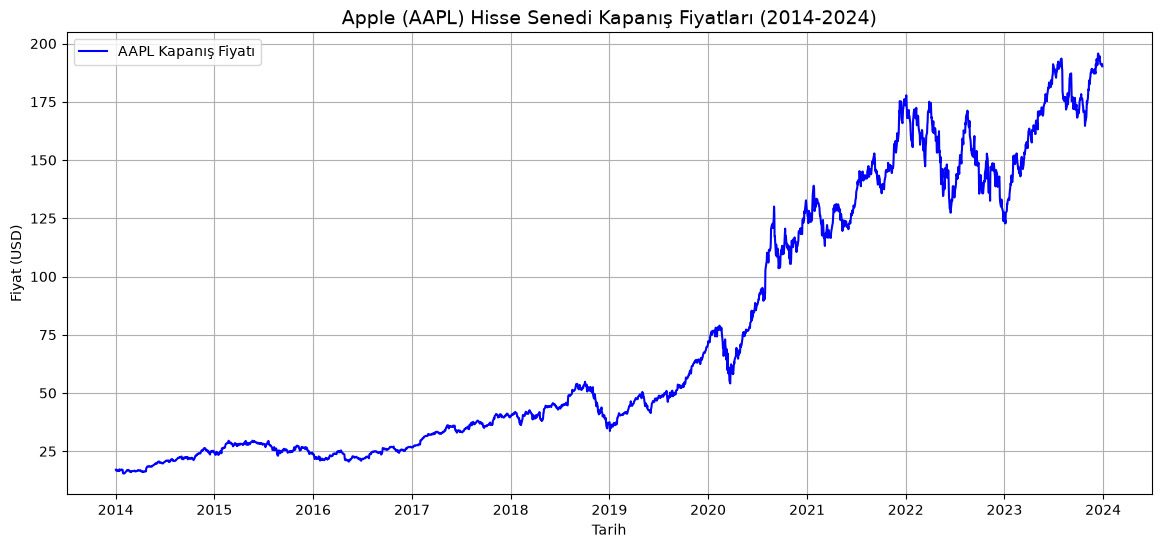

In [2]:
ticker = "AAPL"
# Apple'ın son 10 yıllık verisini çekiyoruz
df = yf.download(ticker, start="2014-01-01", end="2024-01-01")

print("Veri Setinin İlk 5 Satırı:")
print(df.head())

# Sadece Kapanış (Close) fiyatlarını alıp yeniden boyutlandırıyoruz
data = df['Close'].values.reshape(-1, 1)
print("\nVerinin Toplam Boyutu:", data.shape)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='AAPL Kapanış Fiyatı', color='blue')
plt.title('Apple (AAPL) Hisse Senedi Kapanış Fiyatları (2014-2024)', fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Fiyat (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Veri normalizasyonu (-1, 1 aralığı)
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(data)

# Kayan Pencere (Sliding Window) fonksiyonu
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_data, lookback)

# Veri Sızıntısını (Data Leakage) önlemek için kronolojik ayrım (%80 Train, %20 Test)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Verilerin PyTorch tensörlerine dönüştürülmesi ve cihaza gönderilmesi
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

print(f"Eğitim Seti Boyutu (X_train): {X_train_t.shape}")
print(f"Test Seti Boyutu (X_test): {X_test_t.shape}")

Eğitim Seti Boyutu (X_train): torch.Size([1996, 20, 1])
Test Seti Boyutu (X_test): torch.Size([500, 20, 1])


In [4]:
class LSTMModule(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModule, self).__init__()
        # LSTM Katmanı
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Çıktı Katmanı (Fully Connected)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # Sadece en son zaman adımının çıktısını alıyoruz
        out = self.fc(out[:, -1, :])
        return out

class GRUModule(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRUModule, self).__init__()
        # GRU Katmanı
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        # Çıktı Katmanı (Fully Connected)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, _ = self.gru(x)
        # Sadece en son zaman adımının çıktısını alıyoruz
        out = self.fc(out[:, -1, :])
        return out

print("LSTM ve GRU model iskeletleri başarıyla oluşturuldu!")

LSTM ve GRU model iskeletleri başarıyla oluşturuldu!


In [5]:
def train_model(model_class, trial=None):
    # Optuna parametrelerini belirliyoruz
    if trial:
        hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        epochs = 100
    else:
        hidden_dim = 64
        lr = 0.001
        epochs = 100
        
    model = model_class(input_dim=1, hidden_dim=hidden_dim, num_layers=2, output_dim=1).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    start_time = time.time()
    
    # Eğitim Döngüsü
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
    training_time = time.time() - start_time
    
    # Test Seti Üzerinde Değerlendirme
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t)
        test_loss = criterion(test_preds, y_test_t).item()
        
    return model, test_loss, training_time

# Optuna Optimizasyon Fonksiyonu
def objective(trial, model_class):
    _, test_loss, _ = train_model(model_class, trial)
    return test_loss

# 1. LSTM Modelinin Optimizasyonu ve Eğitimi
print("LSTM Modeli Eğitiliyor ve Optimize Ediliyor (Lütfen bekleyin)...")
lstm_study = optuna.create_study(direction='minimize')
lstm_study.optimize(lambda trial: objective(trial, LSTMModule), n_trials=5)
lstm_model, lstm_mse, lstm_time = train_model(LSTMModule, lstm_study.best_trial)

# 2. GRU Modelinin Optimizasyonu ve Eğitimi
print("\nGRU Modeli Eğitiliyor ve Optimize Ediliyor (Lütfen bekleyin)...")
gru_study = optuna.create_study(direction='minimize')
gru_study.optimize(lambda trial: objective(trial, GRUModule), n_trials=5)
gru_model, gru_mse, gru_time = train_model(GRUModule, gru_study.best_trial)

[I 2026-09-06 13:43:46,379] A new study created in memory with name: no-name-c8d7dbfe-20a4-4c90-ad87-117f054db624


LSTM Modeli Eğitiliyor ve Optimize Ediliyor (Lütfen bekleyin)...


[I 2026-09-06 13:44:10,053] Trial 0 finished with value: 0.3839271664619446 and parameters: {'hidden_dim': 128, 'lr': 0.00015978536153395473}. Best is trial 0 with value: 0.3839271664619446.
[I 2026-09-06 13:44:33,699] Trial 1 finished with value: 0.006093468517065048 and parameters: {'hidden_dim': 128, 'lr': 0.002949980314927685}. Best is trial 1 with value: 0.006093468517065048.
[I 2026-09-06 13:44:45,740] Trial 2 finished with value: 0.011092906817793846 and parameters: {'hidden_dim': 64, 'lr': 0.003729468596364975}. Best is trial 1 with value: 0.006093468517065048.
[I 2026-09-06 13:44:57,510] Trial 3 finished with value: 0.011606589891016483 and parameters: {'hidden_dim': 64, 'lr': 0.004188379268881211}. Best is trial 1 with value: 0.006093468517065048.
[I 2026-09-06 13:45:09,292] Trial 4 finished with value: 0.005899238865822554 and parameters: {'hidden_dim': 64, 'lr': 0.0018838625074869867}. Best is trial 4 with value: 0.005899238865822554.
[I 2026-09-06 13:45:20,960] A new study


GRU Modeli Eğitiliyor ve Optimize Ediliyor (Lütfen bekleyin)...


[I 2026-09-06 13:45:31,197] Trial 0 finished with value: 0.3952754735946655 and parameters: {'hidden_dim': 64, 'lr': 0.0001780906672606713}. Best is trial 0 with value: 0.3952754735946655.
[I 2026-09-06 13:45:38,203] Trial 1 finished with value: 0.0030922270379960537 and parameters: {'hidden_dim': 32, 'lr': 0.007077116176056628}. Best is trial 1 with value: 0.0030922270379960537.
[I 2026-09-06 13:45:48,648] Trial 2 finished with value: 0.0020927058067172766 and parameters: {'hidden_dim': 64, 'lr': 0.0020916769346908436}. Best is trial 2 with value: 0.0020927058067172766.
[I 2026-09-06 13:46:07,485] Trial 3 finished with value: 0.002179171424359083 and parameters: {'hidden_dim': 128, 'lr': 0.0010538416806449126}. Best is trial 2 with value: 0.0020927058067172766.
[I 2026-09-06 13:46:14,253] Trial 4 finished with value: 0.06407707184553146 and parameters: {'hidden_dim': 32, 'lr': 0.0003300689220934141}. Best is trial 2 with value: 0.0020927058067172766.



--- SONUÇLAR ---
LSTM Test MSE: 0.009967 | Eğitim Süresi: 11.65 saniye
GRU Test MSE:  0.002063 | Eğitim Süresi: 10.39 saniye


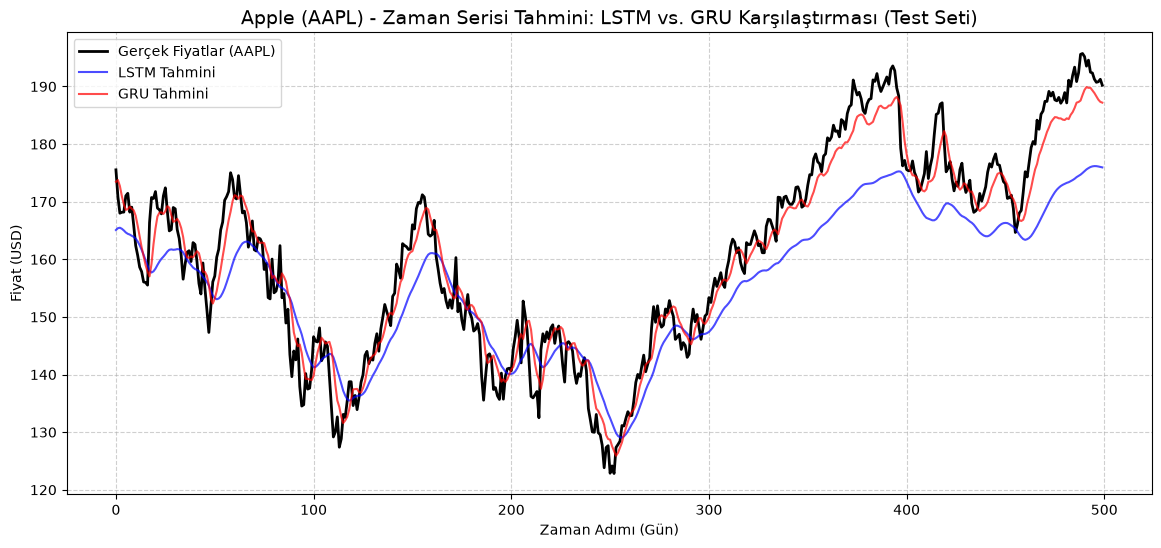

In [6]:
# Tahmin yapma ve gradyan hesaplamasını kapatma
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(X_test_t).cpu().numpy()
    gru_preds = gru_model(X_test_t).cpu().numpy()

# Tahminleri ve gerçek değerleri orijinal ölçeğine (Dolar fiyatına) geri döndürme
lstm_preds_inv = scaler.inverse_transform(lstm_preds)
gru_preds_inv = scaler.inverse_transform(gru_preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Performans Metriklerinin Yazdırılması
print("\n--- SONUÇLAR ---")
print(f"LSTM Test MSE: {lstm_mse:.6f} | Eğitim Süresi: {lstm_time:.2f} saniye")
print(f"GRU Test MSE:  {gru_mse:.6f} | Eğitim Süresi: {gru_time:.2f} saniye")

# Karşılaştırma Grafiği Çizimi
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label='Gerçek Fiyatlar (AAPL)', color='black', linewidth=2)
plt.plot(lstm_preds_inv, label='LSTM Tahmini', color='blue', alpha=0.7)
plt.plot(gru_preds_inv, label='GRU Tahmini', color='red', alpha=0.7)
plt.title('Apple (AAPL) - Zaman Serisi Tahmini: LSTM vs. GRU Karşılaştırması (Test Seti)', fontsize=14)
plt.xlabel('Zaman Adımı (Gün)')
plt.ylabel('Fiyat (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()